Raw GeoJson datasets have separate mapped lines as strings that are stored independently. If an unlabeled road touches a main highway by inspection, the actual coordinates may be misaligned. Topographic correction (similarly used in ESRI GIS analysis steps for Digital Elevation Models) ensured endpoints meet at the same coordinates and are matching a single node. Changing from an OSM highway onto an AI detected road is easier when applying graph theory to connect roads or nodes.

Tuple nodes, or ordered collections/pairs of end points, let any two roads intersect the same location and share the same node.
Node edges (lines connecting them) will be weighted by travel times. 
Edge legnths will be the highway length in meters.
Lines between nodes will be highways.

Instead of trying to find the best path from point A to B with so many unknown dead ends and blocked roads, or networks that can break a lot in the real worlds, let's use the data to make a map that can be reused every time for field workers. Focusing on extracting and mapping the exact set of road segments that can form a path between points in a KD-Tree.

By leveraging spatial KD-Tree lookups, the system extracts and maps the clean, connected road segments and corridors field inspectors need, ensuring a reliable and reusable routing tool for remote operations.

Loading dataset from: C:\Users\308ca\Desktop\Amazonia\Data\combined_roads_paragominas_snapping_union.geojson
Initial Graph ready: 45,129 nodes, 42,886 edges.
Extracting the main connected road network...
Cleaned Graph: 1,825 nodes, 2,072 edges are now fully interconnected.
KD-Tree ready with 1,825 searchable clean nodes.


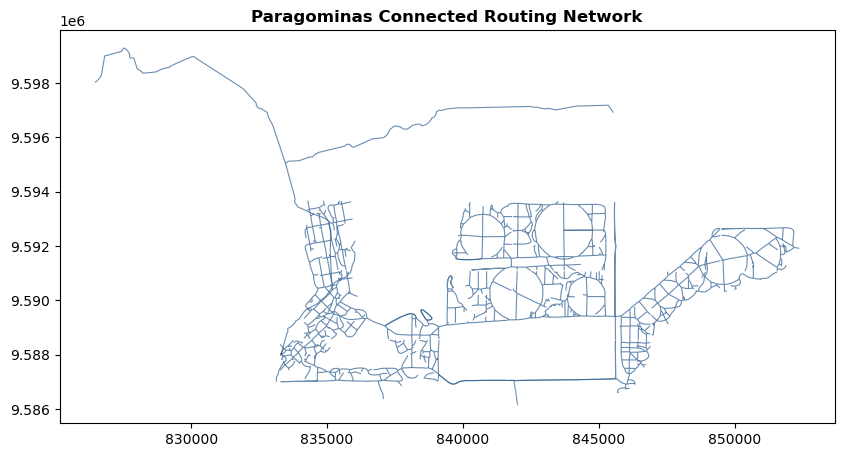


Route Found: 121 intersections | ~121.9 mins
[Saved] GeoJSON exported to: inspector_route.geojson


In [1]:
import geopandas as gpd
import networkx as nx
import pyproj
import numpy as np
from scipy.spatial import KDTree
import matplotlib.pyplot as plt

# 1. Load snapped dataset (UTM 22S metric coordinates) & build initial NetworkX graph
file_path = r"C:\Users\308ca\Desktop\Amazonia\Data\combined_roads_paragominas_snapping_union.geojson"
print(f"Loading dataset from: {file_path}")
gdf = gpd.read_file(file_path)

G_main = nx.MultiDiGraph()

for _, row in gdf.iterrows():
    geom = row['geometry']
    if geom is None or geom.is_empty:
        continue
    for line in ([geom] if geom.geom_type == 'LineString' else list(geom.geoms)):
        coords = list(line.coords)
        G_main.add_edge(
            coords[0], coords[-1],
            weight=row.get('travel_time_hours', 1.0),
            length=row.get('length_meters', line.length),
            highway=row.get('highway', 'unclassified'),
            source=row.get('source', 'unknown'),
            geometry=line
        )

print(f"Initial Graph ready: {G_main.number_of_nodes():,} nodes, {G_main.number_of_edges():,} edges.")

# 2. Extract ONLY the Largest Connected Component FIRST (discards isolated forest stubs & dead ends)
print("Extracting the main connected road network...")
undirected_temp = G_main.to_undirected()
largest_cc = max(nx.connected_components(undirected_temp), key=len)

G_main = G_main.subgraph(largest_cc).copy()
print(f"Cleaned Graph: {G_main.number_of_nodes():,} nodes, {G_main.number_of_edges():,} edges are now fully interconnected.")

# 3. Setup spatial index & bidirectional routing view using the CLEANED graph
transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:31982", always_xy=True)
node_list = list(G_main.nodes())
node_kdtree = KDTree(np.array(node_list))
G_undirected = G_main.to_undirected()
print(f"KD-Tree ready with {len(node_list):,} searchable clean nodes.")

# 4. Robust field routing & export function
# 4. Robust field routing & export function
def route_and_export_for_field(start_lat, start_lon, end_lat, end_lon, output_filename="inspector_route.geojson"):
    start_x, start_y = transformer.transform(start_lon, start_lat)
    end_x, end_y = transformer.transform(end_lon, end_lat)
    
    _, start_idx = node_kdtree.query([start_x, start_y])
    _, end_idx = node_kdtree.query([end_x, end_y])
    src, tgt = node_list[start_idx], node_list[end_idx]
    
    try:
        path_nodes = nx.shortest_path(G_undirected, source=src, target=tgt, weight='weight')
        total_time = nx.shortest_path_length(G_undirected, source=src, target=tgt, weight='weight')
        
        path_gegs, itinerary = [], []
        for u, v in zip(path_nodes[:-1], path_nodes[1:]):
            edge_data = G_main.get_edge_data(u, v)
            if edge_data is None:
                edge_data = G_main.get_edge_data(v, u)
            
            if edge_data is None:
                edge = {'weight': 1.0, 'length': 0, 'highway': 'road', 'source': 'unknown'}
            else:
                edge = min(edge_data.values(), key=lambda x: x['weight'])
                
            path_gegs.append(edge.get('geometry', None))
            itinerary.append({
                'highway': edge.get('highway', 'road'),
                'length_meters': round(edge.get('length', 0), 1),
                'travel_time_mins': round(edge.get('weight', 0) * 60, 1),
                'source_type': edge.get('source', 'unknown')
            })
            
        print(f"\nRoute Found: {len(path_nodes)} intersections | ~{total_time * 60:.1f} mins")
        route_gdf = gpd.GeoDataFrame(itinerary, geometry=path_gegs, crs="EPSG:31982")
        #Add coordinate corversion
        route_gdf = route_gdf.to_crs("EPSG:4326")
        route_gdf.to_file(output_filename, driver="GeoJSON")
        print(f"[Saved] GeoJSON exported to: {output_filename}")
        return route_gdf

    except nx.NetworkXNoPath:
        print("Error: No valid road path connects these two locations.")
        return None

# 5. Quick network visualization of the clean graph
edge_records = [{'geometry': d['geometry']} for _, _, d in G_main.edges(data=True) if 'geometry' in d]
network_gdf = gpd.GeoDataFrame(edge_records, crs="EPSG:31982")

fig, ax = plt.subplots(figsize=(10, 10))
network_gdf.plot(ax=ax, color='#2b5c8f', linewidth=0.8, alpha=0.7)
plt.title("Paragominas Connected Routing Network", fontsize=12, fontweight='bold')
plt.savefig("Paragominas_Connected_Routing_Network_Map.png")
plt.show()

# 6. Execute a test routing query across Paragominas
start_lat, start_lon = -2.985, -47.352  # Near the urban/central hub
end_lat, end_lon = -3.250, -47.820       # Deeper into the rural road network

route_result = route_and_export_for_field(
    start_lat=start_lat, 
    start_lon=start_lon, 
    end_lat=end_lat, 
    end_lon=end_lon, 
    output_filename="inspector_route.geojson"
)

In [2]:
# Save new routing network with no disjointed sets and all nodes and edges connected to traverse
print("Exporting clean connected network to GeoJSON...")
network_gdf_wgs84 = network_gdf.to_crs("EPSG:4326")
network_gdf_wgs84.to_file("clean_routing_network.geojson", driver="GeoJSON")
print(f"[Saved] Clean network exported to: clean_routing_network.geojson")
print(f"Cleaned Graph: {G_main.number_of_nodes():,} nodes, {G_main.number_of_edges():,} edges are now fully interconnected.")

Exporting clean connected network to GeoJSON...
[Saved] Clean network exported to: clean_routing_network.geojson
Cleaned Graph: 1,825 nodes, 2,072 edges are now fully interconnected.


In [3]:
# Example GPS coordinates in Paragominas to test a routing query (replace these with your actual start/end points)
start_lat, start_lon = -2.985, -47.352  # Near the urban/central hub
end_lat, end_lon = -3.250, -47.820       # Deeper into the rural road network

route_result = route_and_export_for_field(
    start_lat=start_lat, 
    start_lon=start_lon, 
    end_lat=end_lat, 
    end_lon=end_lon, 
    output_filename="inspector_route.geojson"
)


Route Found: 121 intersections | ~121.9 mins
[Saved] GeoJSON exported to: inspector_route.geojson


4. Data Cleansing & Topological Alignment
Raw GeoJSON datasets often contain separate, unlinked line strings stored independently. If an unlabeled road visually touches a main highway, their underlying coordinate vertices may actually be misaligned. Topological snapping and geometric alignment ensured that intersecting endpoints share identical coordinates, fusing them into a single, unified node. This bridges the gap when transitioning from an OSM highway onto an AI-detected road vector.

5. Graph Modeling (NetworkX)

Tuple Nodes: Using coordinate pairs (x, y) as node identifiers allows any number of intersecting roads to share the exact same physical location in space.

Edge Weights: Edges (road segments) are weighted by estimated travel time.

Edge Attributes: Stored with length metrics in meters and highway classification types.

6. Strategic Pivot for Field Operations
Instead of trying to find the "best" path from Point A to B across fragile networks riddled with unknown dead ends, blocked roads, and real-world fragmentation, we shifted approach.

The Strategy: Build a reliable, reusable map framework for field workers.

The Implementation: By leveraging spatial KD-Tree lookups, the system extracts and maps the clean, connected road segments and corridors field inspectors need, ensuring a robust and reusable routing tool for remote operations.